`conda activate multi_integration`

# Joint analysis of paired and unpaired multiomic data with scGLUE

## Data preprocessing

In [1]:
import anndata as ad
import networkx as nx
import scanpy as sc
import pandas as pd
import numpy as np
import muon as mu
import scglue
from matplotlib import rcParams

import seaborn as sns
from itertools import chain
from random import Random

# Import a module with ATAC-seq-related functions
from muon import atac as ac

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/cruiz2/miniconda3/envs/multi_integration/l

In [2]:
scglue.plot.set_publication_params()
rcParams["figure.figsize"] = (4, 4)

In [3]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available")
    
    # Get the number of available GPUs
    num_gpus = torch.cuda.device_count()
    print(f"Number of available GPUs: {num_gpus}")
    
    # Get the name of each available GPU
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("CUDA is not available")

CUDA is available
Number of available GPUs: 1
GPU 0: NVIDIA A100-SXM4-40GB


In [4]:
adata_rna_multiome = sc.read('data/subset_rna_multi_dmg_atlas.h5ad')
adata_rna_multiome.obs['modality'] = 'multiome'
adata_rna_multiome.obs['domain'] = 'scRNA-seq'
adata_rna_multiome

AnnData object with n_obs × n_vars = 17875 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [5]:
adata_atac_multiome = sc.read('data/subset_atac_multi_dmg_atlas.h5ad')
adata_atac_multiome.obs['modality'] = 'multiome'
adata_atac_multiome.obs['domain'] = 'scATAC-seq'
adata_atac_multiome

AnnData object with n_obs × n_vars = 17875 × 378298
    obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'passed_filters', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFi

In [6]:
adata_rna = sc.read('data/subset_rna_only_dmg_atlas.h5ad')
adata_rna.obs['modality'] = 'rna'
adata_rna.obs['domain'] = 'scRNA-seq'
adata_rna

AnnData object with n_obs × n_vars = 31118 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [7]:
adata_atac = sc.read('data/subset_atac_only_dmg_atlas.h5ad')
adata_atac.obs['modality'] = 'atac'
adata_atac.obs['domain'] = 'scATAC-seq'
adata_atac

AnnData object with n_obs × n_vars = 21804 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired

### Preprocess scRNA-seq data

In [8]:
adata_rna.X, adata_rna.X.data

(<31118x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 65732976 stored elements in Compressed Sparse Column format>,
 array([1., 1., 1., ..., 1., 1., 1.]))

In [9]:
adata_rna_multiome.X, adata_rna_multiome.X.data

(<17875x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 40637508 stored elements in Compressed Sparse Column format>,
 array([1., 1., 5., ..., 1., 1., 1.]))

In [10]:
rna = adata_rna.concatenate(adata_rna_multiome, index_unique = None)
rna

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


AnnData object with n_obs × n_vars = 48993 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [11]:
rna.layers["counts"] = rna.X.copy()

In [12]:
sc.pp.highly_variable_genes(rna, n_top_genes=2000, flavor="seurat_v3")

In [13]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna)
sc.tl.pca(rna, n_comps=100, svd_solver="auto")

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


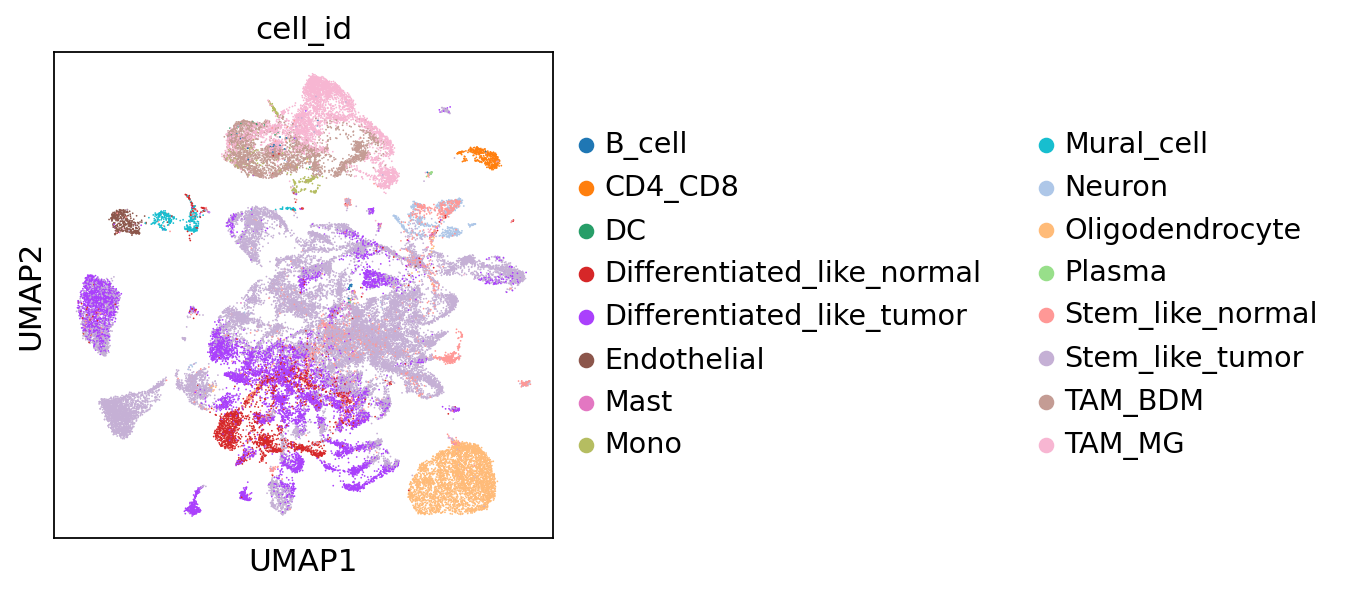

In [14]:
sc.pp.neighbors(rna, metric="cosine")
sc.tl.umap(rna)
sc.pl.umap(rna, color="cell_id")

### Preprocess scATAC-seq data

In [15]:
atac = adata_atac.concatenate(adata_atac_multiome, index_unique = None)
atac

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


AnnData object with n_obs × n_vars = 39679 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired

In [16]:
atac.var_names

Index(['chr1:9729-10741', 'chr1:15764-16590', 'chr1:17055-17946',
       'chr1:28900-29821', 'chr1:180694-181903', 'chr1:183749-184822',
       'chr1:186326-187493', 'chr1:189036-189904', 'chr1:190943-191933',
       'chr1:264326-265168',
       ...
       'KI270731.1:4432-5400', 'KI270731.1:13182-14236',
       'KI270731.1:14520-15440', 'KI270721.1:2096-2993',
       'KI270721.1:3576-4408', 'KI270721.1:8328-10262',
       'KI270721.1:14172-15021', 'KI270721.1:43767-44670',
       'KI270721.1:46484-47618', 'KI270726.1:13856-14767'],
      dtype='object', length=378298)

In [17]:
# Save original counts
atac.layers["counts"] = atac.X.copy()

In [18]:
# https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/2-Chromatin-Accessibility-Processing.html
ac.pp.tfidf(atac, scale_factor=1e4)

In [19]:
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


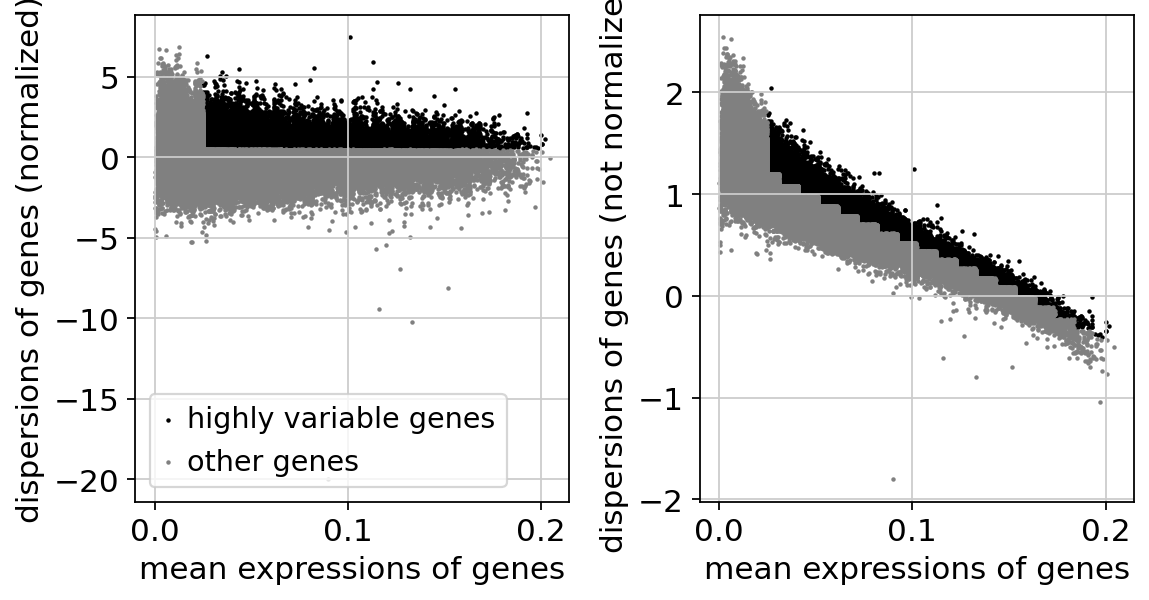

In [20]:
# https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/2-Chromatin-Accessibility-Processing.html
sc.pp.highly_variable_genes(atac, min_mean=0.025,  min_disp=.5)
sc.pl.highly_variable_genes(atac)

In [21]:
np.sum(atac.var.highly_variable)

31899

In [22]:
atac.X, atac.X.data

(<39679x378298 sparse matrix of type '<class 'numpy.float64'>'
 	with 300355021 stored elements in Compressed Sparse Row format>,
 array([0.60589039, 0.36504491, 0.61653304, ..., 0.81672659, 0.58483244,
        0.35535224]))

In [23]:
# after performing the selection of highly variable peaks, we revert adata.X back to raw counts

atac.X = atac.layers["counts"].copy()
atac.X, atac.X.data

(<39679x378298 sparse matrix of type '<class 'numpy.float64'>'
 	with 300355021 stored elements in Compressed Sparse Row format>,
 array([2., 1., 1., ..., 1., 1., 1.]))

In [24]:
scglue.data.lsi(atac, n_components=100, n_iter=15, use_highly_variable = True)

In [25]:
sc.pp.neighbors(atac, use_rep="X_lsi", metric="cosine")
sc.tl.umap(atac)

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


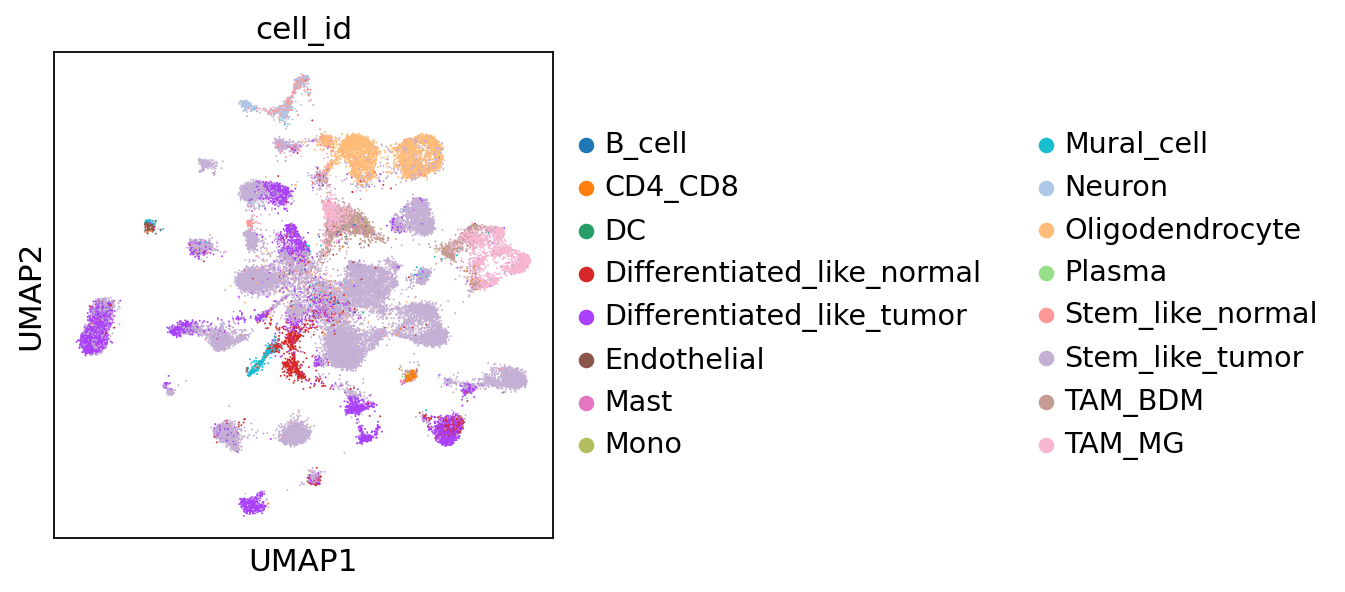

In [26]:
sc.pl.umap(atac, color="cell_id")

## Construct prior regulatory graph

### Obtain genomic coordinates

In [27]:
rna.var.head()

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable,highly_variable,highly_variable_rank,means,variances,variances_norm,mean,std
A1BG,0.631716,1202.719885,373.474371,3.220355,True,False,NaN,0.074296,0.105396,0.725531,0.031484,0.153295
A1CF,0.068691,39.460411,37.081347,1.064158,False,False,NaN,0.003347,0.004520,0.930225,0.001805,0.040655
A2M,5.611721,15361.999192,7507.142953,2.046318,False,True,662.0,0.949911,18.401190,3.184670,0.258231,0.556005
A2ML1,0.252424,449.444287,142.899698,3.138113,True,False,NaN,0.045088,0.103474,1.277333,0.021481,0.142888
A3GALT2,0.042899,6.267352,22.382860,0.280007,False,False,NaN,0.007246,0.007928,0.706589,0.003529,0.054100


In [28]:
scglue.data.get_gene_annotation(
    rna, gtf="/home/cruiz2/software/refdata-gex-GRCh38-2020-A/genes/genes.gtf",
    gtf_by="gene_name"
)
rna.var.loc[:, ["chrom", "chromStart", "chromEnd"]].head()

,chrom,chromStart,chromEnd
A1BG,chr19,58345177,58353492
A1CF,chr10,50799408,50885675
A2M,chr12,9067663,9116229
A2ML1,chr12,8822620,8887001
A3GALT2,chr1,33306765,33321098


In [29]:
split = atac.var_names.str.split(r"[:-]")
atac.var["chrom"] = split.map(lambda x: x[0])
atac.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
atac.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)
atac.var.head()

,count-0,percentile-0,count-1,percentile-1,highly_variable,means,dispersions,dispersions_norm,chrom,chromStart,chromEnd
chr1:9729-10741,121.0,0.168346,678.0,0.884990,False,0.030633,1.190068,0.443980,chr1,9729,10741
chr1:15764-16590,41.0,0.008834,60.0,0.027685,False,0.004292,1.100745,-1.247655,chr1,15764,16590
chr1:17055-17946,71.0,0.035287,87.0,0.109028,False,0.007263,1.316502,-0.047658,chr1,17055,17946
chr1:28900-29821,16.0,0.001745,105.0,0.189356,False,0.006739,1.561703,1.316111,chr1,28900,29821
chr1:180694-181903,740.0,0.853930,1714.0,0.959090,True,0.075919,1.026953,3.284671,chr1,180694,181903


### Graph construction

In [30]:
guidance = scglue.genomics.rna_anchored_guidance_graph(rna, atac)
guidance

window_graph: 100%|██████████████████████████████████████████████████████████████████████████████████| 19248/19248 [00:04<00:00, 4615.93it/s]


In [31]:
scglue.graph.check_graph(guidance, [rna, atac])

[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] check_graph: All checks passed!


In [32]:
atac.var.head()

,count-0,percentile-0,count-1,percentile-1,highly_variable,means,dispersions,dispersions_norm,chrom,chromStart,chromEnd
chr1:9729-10741,121.0,0.168346,678.0,0.884990,False,0.030633,1.190068,0.443980,chr1,9729,10741
chr1:15764-16590,41.0,0.008834,60.0,0.027685,False,0.004292,1.100745,-1.247655,chr1,15764,16590
chr1:17055-17946,71.0,0.035287,87.0,0.109028,False,0.007263,1.316502,-0.047658,chr1,17055,17946
chr1:28900-29821,16.0,0.001745,105.0,0.189356,False,0.006739,1.561703,1.316111,chr1,28900,29821
chr1:180694-181903,740.0,0.853930,1714.0,0.959090,False,0.075919,1.026953,3.284671,chr1,180694,181903


In [33]:
rna.write("mosaic_integration/scglue/general/rna-pp.h5ad", compression="gzip")
atac.write("mosaic_integration/scglue/general/atac-pp.h5ad", compression="gzip")
nx.write_graphml(guidance, "mosaic_integration/scglue/general/rguidance.graphml.gz")

## Model training on partially paired data

### Configure data

In [34]:
scglue.models.configure_dataset(
    rna, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_pca",
    use_obs_names=True
)

In [35]:
scglue.models.configure_dataset(
    atac, "NB", use_highly_variable=True,
    use_rep="X_lsi",
    use_obs_names=True
)

In [36]:
guidance_hvf = guidance.subgraph(chain(
    rna.var.query("highly_variable").index,
    atac.var.query("highly_variable").index
)).copy()

### Train GLUE model

In [37]:
glue = scglue.models.fit_SCGLUE(
    {"rna": rna, "atac": atac}, guidance_hvf,
    model=scglue.models.PairedSCGLUEModel,
    fit_kws={"directory": "glue_a"}
)

[INFO] fit_SCGLUE: Pretraining SCGLUE model...
[INFO] autodevice: Using GPU 0 as computation device.
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] PairedSCGLUEModel: Setting `graph_batch_size` = 40152
[INFO] PairedSCGLUEModel: Setting `max_epochs` = 49
[INFO] PairedSCGLUEModel: Setting `patience` = 5
[INFO] PairedSCGLUEModel: Setting `reduce_lr_patience` = 3
[INFO] PairedSCGLUETrainer: Using training directory: "glue_a/pretrain"
[INFO] PairedSCGLUETrainer: [Epoch 10] train={'g_nll': 0.41, 'g_kl': 0.003, 'g_elbo': 0.414, 'x_rna_nll': 0.335, 'x_rna_kl': 0.014, 'x_rna_elbo': 0.349, 'x_atac_nll': 0.079, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.08, 'dsc_loss': 0.692, 'vae_loss': 0.465, 'gen_loss': 0.43, 'joint_cross_loss': 0.415, 'real_cross_loss': 0.451, 'cos_loss': 0.107}, val={'g_nll': 0.41, 'g_kl': 0.003, 'g_elbo': 0.414, 'x_rna_nll': 0.329, 'x

2023-05-22 15:58:54,974 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "20"...
[INFO] EarlyStopping: Restoring checkpoint "20"...
[INFO] fit_SCGLUE: Estimating balancing weight...
[INFO] estimate_balancing_weight: Clustering cells...
[INFO] estimate_balancing_weight: Matching clusters...
[INFO] estimate_balancing_weight: Matching array shape = (50, 36)...
[INFO] estimate_balancing_weight: Estimating balancing weight...


/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


[INFO] fit_SCGLUE: Fine-tuning SCGLUE model...
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] PairedSCGLUEModel: Setting `graph_batch_size` = 40152
[INFO] PairedSCGLUEModel: Setting `align_burnin` = 9
[INFO] PairedSCGLUEModel: Setting `max_epochs` = 49
[INFO] PairedSCGLUEModel: Setting `patience` = 5
[INFO] PairedSCGLUEModel: Setting `reduce_lr_patience` = 3
[INFO] PairedSCGLUETrainer: Using training directory: "glue_a/fine-tune"
[INFO] PairedSCGLUETrainer: [Epoch 10] train={'g_nll': 0.407, 'g_kl': 0.003, 'g_elbo': 0.41, 'x_rna_nll': 0.334, 'x_rna_kl': 0.013, 'x_rna_elbo': 0.348, 'x_atac_nll': 0.079, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.08, 'dsc_loss': 0.675, 'vae_loss': 0.464, 'gen_loss': 0.43, 'joint_cross_loss': 0.414, 'real_cross_loss': 0.452, 'cos_loss': 0.112}, val={'g_nll': 0.407, 'g_kl': 0.003, 'g_elbo': 0.41, 'x_rna_nll': 0.329, 'x

2023-05-22 16:38:58,631 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "24"...
[INFO] EarlyStopping: Restoring checkpoint "24"...


In [38]:
dx = scglue.models.integration_consistency(
    glue, {"rna": rna, "atac": atac}, guidance_hvf
)
dx

[INFO] integration_consistency: Using layer "counts" for modality "rna"
[INFO] integration_consistency: Selecting aggregation "sum" for modality "rna"
[INFO] integration_consistency: Selecting aggregation "sum" for modality "atac"
[INFO] integration_consistency: Selecting log-norm preprocessing for modality "rna"
[INFO] integration_consistency: Selecting log-norm preprocessing for modality "atac"
[INFO] get_metacells: Clustering metacells...


/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 10 common metacells...
[INFO] get_metacells: Clustering metacells...


/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 20 common metacells...
[INFO] get_metacells: Clustering metacells...


...

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 100 common metacells...
[INFO] get_metacells: Clustering metacells...


/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 199 common metacells...


,n_meta,consistency
0,10,0.273868
1,20,0.340024
2,50,0.351797
3,100,0.262271
4,200,0.195560


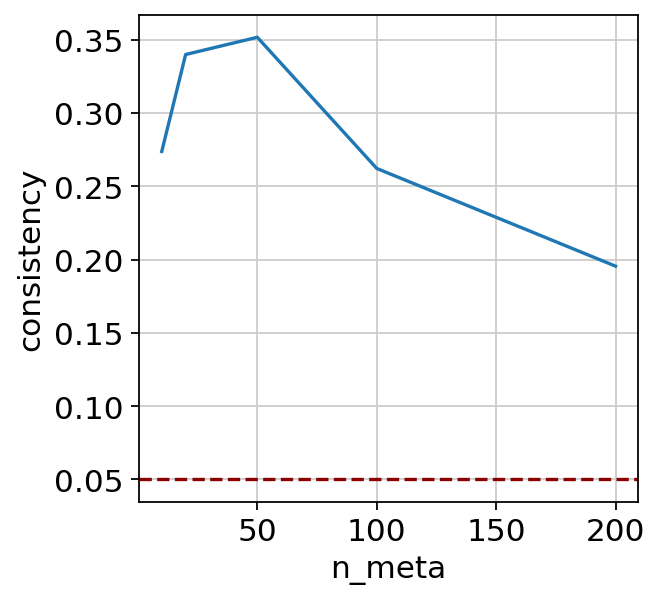

In [39]:
_ = sns.lineplot(x="n_meta", y="consistency", data=dx).axhline(y=0.05, c="darkred", ls="--")

In [40]:
rna.obsm["X_glue"] = glue.encode_data("rna", rna)
atac.obsm["X_glue"] = glue.encode_data("atac", atac)

In [41]:
combined = ad.concat([rna, atac])

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


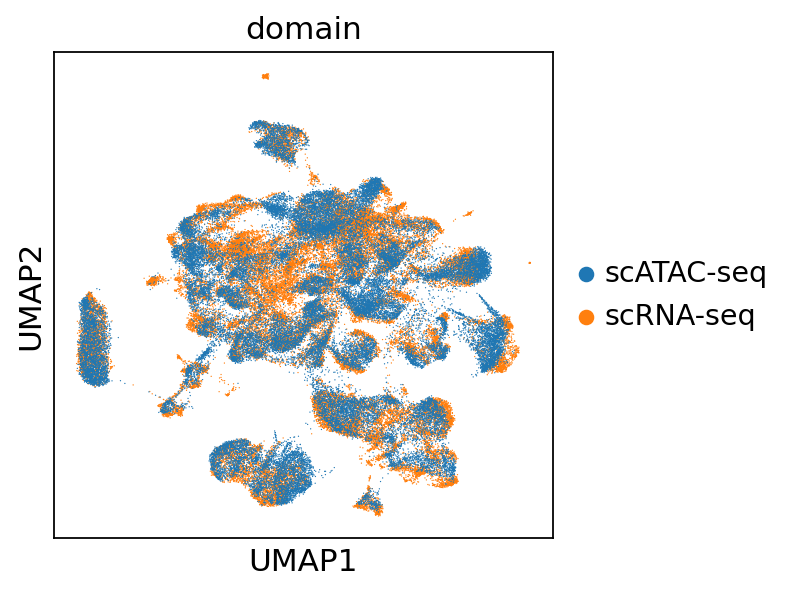

In [42]:
sc.pp.neighbors(combined, use_rep="X_glue", metric="cosine")
sc.tl.umap(combined)
sc.pl.umap(combined, color=["domain"], wspace=0.65)

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


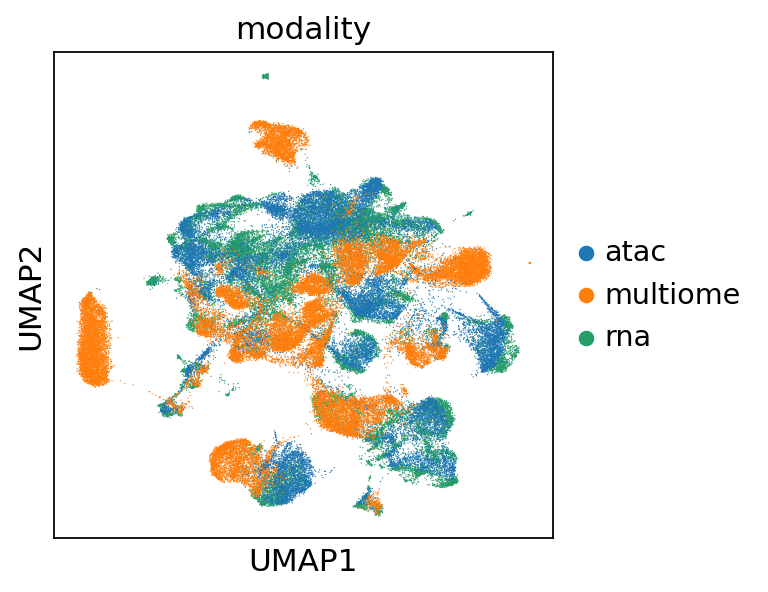

In [43]:
sc.pl.umap(combined, color=["modality"], wspace=0.65)

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


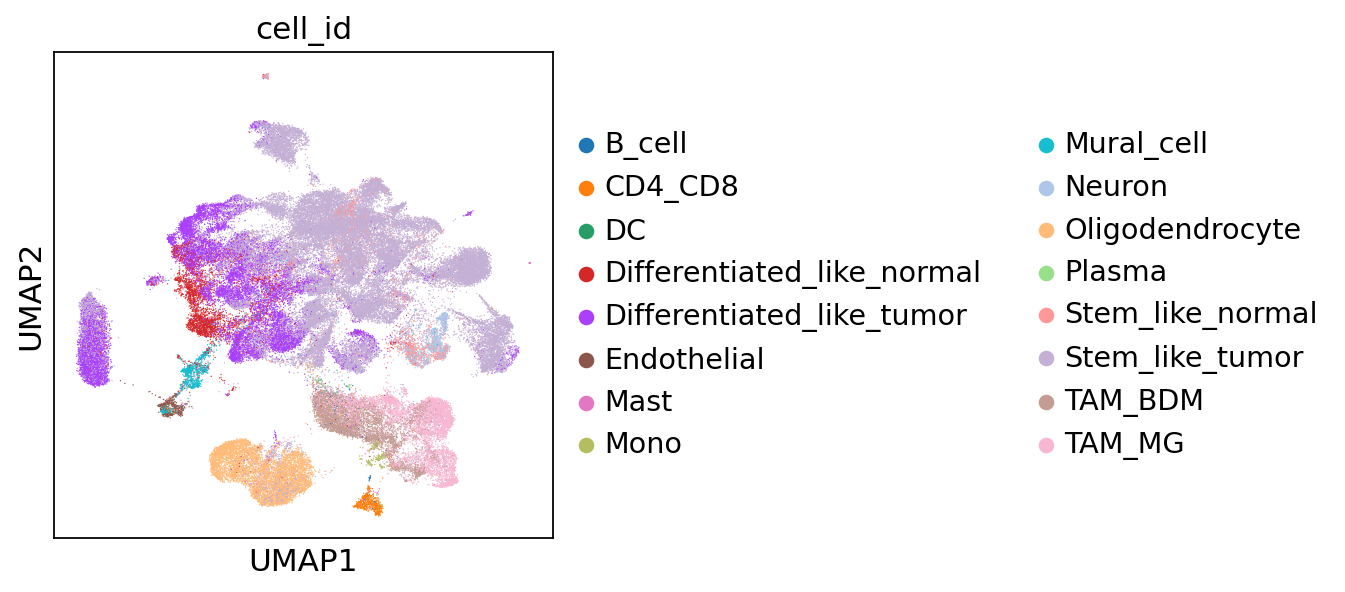

In [44]:
sc.pl.umap(combined, color=["cell_id"], wspace=0.65)

In [45]:
combined.write("mosaic_integration/scglue/modality/dmg_atlas_subset_scglue_modality.h5ad", compression="gzip")

In [46]:
feature_embeddings = glue.encode_graph(guidance_hvf)
feature_embeddings = pd.DataFrame(feature_embeddings, index=glue.vertices)
feature_embeddings.iloc[:5, :5]

,0,1,2,3,4
A2M,-0.440386,-0.129767,0.040242,-0.012363,-0.014229
ABCA10,-0.671803,0.319551,-1.069720,-0.005629,-0.003352
ABCA13,-0.016591,-0.025250,0.478086,-0.000189,0.011825
ABCA4,-0.388397,0.868972,-0.867644,-0.001610,0.005862
ABCA6,-0.802744,0.402893,-0.758106,-0.006372,-0.008521


In [47]:
rna.varm["X_glue"] = feature_embeddings.reindex(rna.var_names).to_numpy()
atac.varm["X_glue"] = feature_embeddings.reindex(atac.var_names).to_numpy()

In [48]:
rna.write("mosaic_integration/scglue/modality/rna-emb.h5ad", compression="gzip")
atac.write("mosaic_integration/scglue/modality/atac-emb.h5ad", compression="gzip")
nx.write_graphml(guidance_hvf, "mosaic_integration/scglue/modality/guidance-hvf.graphml.gz")